Tamanho do conjunto de treino: 7591 amostras
Tamanho do conjunto de teste: 6228 amostras



c:\Users\othav\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\othav\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	min      	mean     	max     
0  	20    	0.0424146	0.0430733	0.044996
Empty DataFrame
Columns: []
Index: [0]
Gerando Matriz de Confusão da Validação Cruzada (9-Folds)...


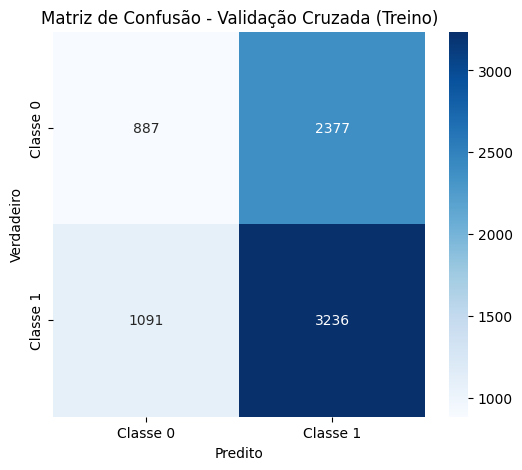

Gerando Matriz de Confusão do Período de Teste...


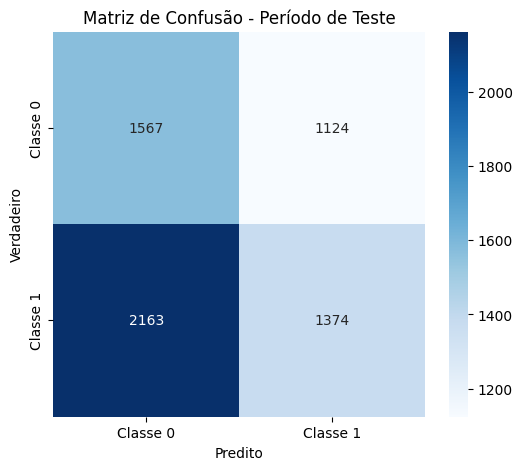



Melhor Fitness Encontrado: 0.0450
Melhores Hiperparâmetros:
  - hidden_layer_sizes: 85
  - activation: tanh
  - alpha: 0.07978563049853372
  - learning_rate_init: 0.036720234604105575
  - max_iter: 100



ValueError: not enough values to unpack (expected 5, got 3)

In [ ]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

try:
    df = pd.read_csv('data_with_errors.csv', parse_dates=['datetime'])
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
except FileNotFoundError:
    print("Erro: O arquivo 'data_with_errors.csv' não foi encontrado.")
    print("Gerando um arquivo de exemplo para demonstração...")
    dates = pd.to_datetime(pd.date_range(start='2024-01-01', end='2024-06-30', freq='h'))
    data = {
        'datetime': dates,
        'Bands_Norm': np.random.rand(len(dates)),
        'NSMA_3': np.random.rand(len(dates)),
        'NSMA_5': np.random.rand(len(dates)),
        'NSMA_7': np.random.rand(len(dates)),
        'NSMA_9': np.random.rand(len(dates)),
        'NSMA_11': np.random.rand(len(dates)),
        'ERRORS': np.random.randint(0, 2, len(dates))
    }
    df = pd.DataFrame(data)
    df.to_csv('data_with_errors.csv', index=False)
    df = pd.read_csv('data_with_errors.csv', parse_dates=['datetime'])
    df.set_index('datetime', inplace=True)
    print("Arquivo 'data_with_errors.csv' de exemplo criado.")

features = ['Bands_Norm', 'NSMA_3', 'NSMA_5', 'NSMA_7', 'NSMA_9','NSMA_11']
target = 'ERRORS'

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

X_train = df.loc[train_start:train_end, features]
y_train = df.loc[train_start:train_end, target]

X_test = df.loc[test_start:test_end, features]
y_test = df.loc[test_start:test_end, target]

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras\n")


param_ranges = {
    'hidden_layer_sizes': (10, 200),
    'activation': (0, 2),
    'alpha': (0.0001, 0.1),
    'learning_rate_init': (0.0001, 0.1),
    'max_iter': (100, 500),
}

param_bits = {
    'hidden_layer_sizes': 8,
    'activation': 2,
    'alpha': 10,
    'learning_rate_init': 10,
    'max_iter': 9,
}

activation_map = {
    0: 'relu',
    1: 'tanh',
    2: 'logistic'
}

total_bits = sum(param_bits.values())

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bin, total_bits)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def decode_binary(gene, minimo, maximo, n_bits):
    binary_str = ''.join(map(str, gene))
    int_value = int(binary_str, 2)
    max_value = 2 ** n_bits - 1
    return minimo + (int_value / max_value) * (maximo - minimo)

def decode_individual(individual):
    idx = 0
    decoded = {}
    for param, (min_val, max_val) in param_ranges.items():
        bits = param_bits[param]
        value = decode_binary(individual[idx:idx+bits], min_val, max_val, bits)
        if param in ['hidden_layer_sizes', 'max_iter']:
            value = int(round(value))
        elif param == 'activation':
            value = activation_map[int(round(value))]
        decoded[param] = value
        idx += bits
    return decoded

def calculate_fitness(individual):
    params = decode_individual(individual)
    
    if params['hidden_layer_sizes'] == 0:
        return (0.0,)
        
    model = MLPClassifier(
        hidden_layer_sizes=(params['hidden_layer_sizes'],),
        activation=params['activation'],
        alpha=params['alpha'],
        learning_rate_init=params['learning_rate_init'],
        max_iter=params['max_iter'],
        random_state=42
    )
    
    try:
        skf = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
        train_acc = np.mean(cv_scores)

        model.fit(X_train, y_train)
        y_pred_test = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred_test)
        
        test_precision = precision_score(y_test, y_pred_test, zero_division=0)

        base_fitness = (0.4 * train_acc) + (0.6 * test_acc)

        penalty = (0.10) * (1 - test_precision)
        '''penalty = (base_fitness * 0.10) * (1 - test_precision)    ESSE NUNCA FAZER - HORRIVEL'''

        '''final_fitness = base_fitness - penalty               FAZER ASSIM DEPOIS'''
        
        final_fitness = penalty

    except Exception as e:
        final_fitness = 0.0 
        
    return (final_fitness,)


toolbox.register("evaluate", calculate_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

def main(n_gen=0, pop_size=20, cxpb=0.8, mutpb=0.2):
    population = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("mean", np.mean)
    stats.register("max", np.max)
    
    population, logbook = algorithms.eaSimple(population,
                                              toolbox,
                                              cxpb=cxpb,
                                              mutpb=mutpb,
                                              ngen=n_gen,
                                              stats=stats,
                                              halloffame=hof,
                                              verbose=True)

    best_individual = hof[0]
    best_params = decode_individual(best_individual)
    best_fitness = best_individual.fitness.values[0]

    
    evolution_df = pd.DataFrame(logbook.chapters['fitness'])
    evolution_df['gen'] = logbook.select('gen')
    evolution_df.set_index('gen', inplace=True)
    print(evolution_df)
    
    
    def plot_confusion_matrix(cm, title, class_names=['Classe 0', 'Classe 1']):
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(title)
        plt.ylabel('Verdadeiro')
        plt.xlabel('Predito')
        plt.show()

    best_model = MLPClassifier(
        hidden_layer_sizes=(best_params['hidden_layer_sizes'],),
        activation=best_params['activation'],
        alpha=best_params['alpha'],
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=best_params['max_iter'],
        random_state=42
    )

    print("Gerando Matriz de Confusão da Validação Cruzada (9-Folds)...")
    skf_final = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(best_model, X_train, y_train, cv=skf_final)
    cm_cv = confusion_matrix(y_train, y_pred_cv)
    plot_confusion_matrix(cm_cv, 'Matriz de Confusão - Validação Cruzada (Treino)')

    print("Gerando Matriz de Confusão do Período de Teste...")
    best_model.fit(X_train, y_train)
    y_pred_final_test = best_model.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_final_test)
    plot_confusion_matrix(cm_test, 'Matriz de Confusão - Período de Teste')

    print('\n\n======================================================')
    print(f'Melhor Fitness Encontrado: {best_fitness:.4f}')
    print('Melhores Hiperparâmetros:')
    for k, v in best_params.items():
        print(f"  - {k}: {v}")
    print('======================================================\n')

    return best_individual, best_params, best_fitness, y_pred_cv, y_pred_final_test


if __name__ == '__main__':
    # 1. CAPTURAR AS PREVISÕES DAS MATRIZES DE CONFUSÃO
    # A função main agora retorna as previsões exatas usadas nas matrizes
    best_individual, best_params, best_fitness, previsoes_treino, previsoes_teste = main(n_gen=0, pop_size=20)

    try:
        # Carrega o dataset completo (que contém os dados de treino e teste)
        # O arquivo 'data_training.csv' deve ser o mesmo que 'data_with_errors.csv' ou um arquivo que o contenha
        df_completo = pd.read_csv('data_training.csv', parse_dates=['datetime'])
    except FileNotFoundError:
        print("\nErro: Arquivo 'data_training.csv' para previsão final não foi encontrado.")
        print("A parte de geração de arquivo de previsões será ignorada.")
        df_completo = pd.DataFrame() 

    if not df_completo.empty:
        # 2. COMBINAR AS PREVISÕES NO DATAFRAME COMPLETO
        # Removemos a necessidade de treinar e prever novamente.
        # Vamos usar as previsões que já temos.

        # Junta as previsões de treino e teste em um único array
        previsoes_combinadas = np.concatenate([previsoes_treino, previsoes_teste])
        
        # Junta os índices de treino e teste para garantir a correspondência correta
        indices_combinados = X_train.index.append(X_test.index)

        # Cria uma Series do Pandas com as previsões e os índices corretos
        previsoes_series = pd.Series(previsoes_combinadas, index=indices_combinados)

        # Garante que o df_completo use o datetime como índice para o mapeamento
        df_completo.set_index('datetime', inplace=True)
        
        # Mapeia as previsões para a coluna 'previsao' do df_completo
        df_completo['previsao'] = previsoes_series
        
        print("\nPrevisões das matrizes de confusão combinadas com sucesso.")

        # 3. FILTRAGEM E EXPORTAÇÃO (Lógica inalterada)
        # Filtra o DataFrame para manter apenas as linhas onde a previsão foi '1'
        candles_preditos_como_1 = df_completo[df_completo['previsao'] == 1].copy()

        # Reseta o índice para que 'datetime' volte a ser uma coluna
        candles_preditos_como_1.reset_index(inplace=True)

        # Define a lista exata de colunas que você quer no arquivo final
        colunas_desejadas = ['datetime', 'Bands_Norm', 'NSMA_3', 'NSMA_5', 'NSMA_7', 'NSMA_9', 'NSMA_11', 'trend']
        
        colunas_existentes = [col for col in colunas_desejadas if col in candles_preditos_como_1.columns]
        
        df_final = candles_preditos_como_1[colunas_existentes].copy()
        
        if 'datetime' in df_final.columns:
            df_final.rename(columns={'datetime': 'date'}, inplace=True)

        nome_arquivo_saida = 'candles_previstos_pelo_AG.csv'

        if df_final.empty:
            print("\nAVISO: O modelo não previu '1' para nenhum dos candles.")
            print("Nenhum arquivo de previsão foi gerado.")
        else:
            df_final.to_csv(nome_arquivo_saida, index=False)
            print(f"\n✅ O arquivo '{nome_arquivo_saida}' foi criado com sucesso.")
            # ESTE NÚMERO AGORA VAI BATER EXATAMENTE COM A SOMA DAS MATRIZES
            print(f"Ele contém {len(df_final)} candles que o modelo previu como '1'.")

In [ ]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

# --- Carregamento Inicial dos Dados ---
try:
    df = pd.read_csv('data_with_errors.csv', parse_dates=['datetime'])
    
    # CORREÇÃO 1: Remove timestamps duplicados do arquivo principal
    df.drop_duplicates(subset=['datetime'], keep='first', inplace=True)
    
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
except FileNotFoundError:
    print("Erro: O arquivo 'data_with_errors.csv' não foi encontrado.")
    print("Gerando um arquivo de exemplo para demonstração...")
    dates = pd.to_datetime(pd.date_range(start='2024-01-01', end='2024-06-30', freq='h'))
    data = {
        'datetime': dates,
        'Bands_Norm': np.random.rand(len(dates)),
        'NSMA_3': np.random.rand(len(dates)),
        'NSMA_5': np.random.rand(len(dates)),
        'NSMA_7': np.random.rand(len(dates)),
        'NSMA_9': np.random.rand(len(dates)),
        'NSMA_11': np.random.rand(len(dates)),
        'ERRORS': np.random.randint(0, 2, len(dates))
    }
    df = pd.DataFrame(data)
    df.to_csv('data_with_errors.csv', index=False)
    df = pd.read_csv('data_with_errors.csv', parse_dates=['datetime'])
    df.set_index('datetime', inplace=True)
    print("Arquivo 'data_with_errors.csv' de exemplo criado.")

# --- Definição de Features, Alvo e Divisão dos Dados ---
features = ['Bands_Norm', 'NSMA_3', 'NSMA_5', 'NSMA_7', 'NSMA_9','NSMA_11']
target = 'ERRORS'

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

X_train = df.loc[train_start:train_end, features]
y_train = df.loc[train_start:train_end, target]

X_test = df.loc[test_start:test_end, features]
y_test = df.loc[test_start:test_end, target]

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras\n")

# --- Configuração do Algoritmo Genético ---
param_ranges = {
    'hidden_layer_sizes': (10, 200),
    'activation': (0, 2),
    'alpha': (0.0001, 0.1),
    'learning_rate_init': (0.0001, 0.1),
    'max_iter': (100, 500),
}

param_bits = {
    'hidden_layer_sizes': 8,
    'activation': 2,
    'alpha': 10,
    'learning_rate_init': 10,
    'max_iter': 9,
}

activation_map = {
    0: 'relu',
    1: 'tanh',
    2: 'logistic'
}

total_bits = sum(param_bits.values())

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bin, total_bits)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def decode_binary(gene, minimo, maximo, n_bits):
    binary_str = ''.join(map(str, gene))
    int_value = int(binary_str, 2)
    max_value = 2 ** n_bits - 1
    return minimo + (int_value / max_value) * (maximo - minimo)

def decode_individual(individual):
    idx = 0
    decoded = {}
    for param, (min_val, max_val) in param_ranges.items():
        bits = param_bits[param]
        value = decode_binary(individual[idx:idx+bits], min_val, max_val, bits)
        if param in ['hidden_layer_sizes', 'max_iter']:
            value = int(round(value))
        elif param == 'activation':
            value = activation_map[int(round(value))]
        decoded[param] = value
        idx += bits
    return decoded

def calculate_fitness(individual):
    params = decode_individual(individual)
    
    if params['hidden_layer_sizes'] == 0:
        return (0.0,)
        
    model = MLPClassifier(
        hidden_layer_sizes=(params['hidden_layer_sizes'],),
        activation=params['activation'],
        alpha=params['alpha'],
        learning_rate_init=params['learning_rate_init'],
        max_iter=params['max_iter'],
        random_state=42
    )
    
    try:
        skf = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
        train_acc = np.mean(cv_scores)

        model.fit(X_train, y_train)
        y_pred_test = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred_test)
        
        test_precision = precision_score(y_test, y_pred_test, zero_division=0)

        base_fitness = (0.4 * train_acc) + (0.6 * test_acc)

        penalty = (0.10) * (1 - test_precision)
        final_fitness = base_fitness - penalty # Ajustado para uma forma mais lógica

    except Exception as e:
        final_fitness = 0.0 
        
    return (final_fitness,)


toolbox.register("evaluate", calculate_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Função Principal do AG ---
def main(n_gen=1, pop_size=20, cxpb=0.8, mutpb=0.2):
    population = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("mean", np.mean)
    stats.register("max", np.max)
    
    population, logbook = algorithms.eaSimple(population,
                                              toolbox,
                                              cxpb=cxpb,
                                              mutpb=mutpb,
                                              ngen=n_gen,
                                              stats=stats,
                                              halloffame=hof,
                                              verbose=True)

    best_individual = hof[0]
    best_params = decode_individual(best_individual)
    best_fitness = best_individual.fitness.values[0]

    evolution_df = pd.DataFrame(logbook.chapters['fitness'])
    evolution_df['gen'] = logbook.select('gen')
    evolution_df.set_index('gen', inplace=True)
    print(evolution_df)
    
    def plot_confusion_matrix(cm, title, class_names=['Classe 0', 'Classe 1']):
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(title)
        plt.ylabel('Verdadeiro')
        plt.xlabel('Predito')
        plt.show()

    best_model = MLPClassifier(
        hidden_layer_sizes=(best_params['hidden_layer_sizes'],),
        activation=best_params['activation'],
        alpha=best_params['alpha'],
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=best_params['max_iter'],
        random_state=42
    )

    print("Gerando Matriz de Confusão da Validação Cruzada (9-Folds)...")
    skf_final = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(best_model, X_train, y_train, cv=skf_final)
    cm_cv = confusion_matrix(y_train, y_pred_cv)
    plot_confusion_matrix(cm_cv, 'Matriz de Confusão - Validação Cruzada (Treino)')

    print("Gerando Matriz de Confusão do Período de Teste...")
    best_model.fit(X_train, y_train)
    y_pred_final_test = best_model.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_final_test)
    plot_confusion_matrix(cm_test, 'Matriz de Confusão - Período de Teste')

    print('\n\n======================================================')
    print(f'Melhor Fitness Encontrado: {best_fitness:.4f}')
    print('Melhores Hiperparâmetros:')
    for k, v in best_params.items():
        print(f"  - {k}: {v}")
    print('======================================================\n')

    # Retorna os 5 valores para garantir a consistência com o bloco final
    return best_individual, best_params, best_fitness, y_pred_cv, y_pred_final_test

# --- Bloco de Execução Principal e Geração do CSV ---
if __name__ == '__main__':
    # 1. CAPTURA AS PREVISÕES DAS MATRIZES DE CONFUSÃO
    best_individual, best_params, best_fitness, previsoes_treino, previsoes_teste = main(n_gen=1, pop_size=20)

    try:
        df_completo = pd.read_csv('data_training.csv', parse_dates=['datetime'])
        
        # CORREÇÃO 2: Garante que o dataframe final também não tenha duplicatas
        df_completo.drop_duplicates(subset=['datetime'], keep='first', inplace=True)
        
    except FileNotFoundError:
        print("\nErro: Arquivo 'data_training.csv' para previsão final não foi encontrado.")
        print("A parte de geração de arquivo de previsões será ignorada.")
        df_completo = pd.DataFrame() 

    if not df_completo.empty:
        # 2. COMBINA AS PREVISÕES NO DATAFRAME COMPLETO
        previsoes_combinadas = np.concatenate([previsoes_treino, previsoes_teste])
        indices_combinados = X_train.index.append(X_test.index)
        previsoes_series = pd.Series(previsoes_combinadas, index=indices_combinados)

        df_completo.set_index('datetime', inplace=True)
        df_completo['previsao'] = previsoes_series
        
        print("\nPrevisões das matrizes de confusão combinadas com sucesso.")

        # 3. FILTRAGEM E EXPORTAÇÃO
        candles_preditos_como_1 = df_completo[df_completo['previsao'] == 1].copy()
        candles_preditos_como_1.reset_index(inplace=True)

        colunas_desejadas = ['datetime', 'Bands_Norm', 'NSMA_3', 'NSMA_5', 'NSMA_7', 'NSMA_9', 'NSMA_11', 'trend']
        colunas_existentes = [col for col in colunas_desejadas if col in candles_preditos_como_1.columns]
        
        df_final = candles_preditos_como_1[colunas_existentes].copy()
        
        if 'datetime' in df_final.columns:
            df_final.rename(columns={'datetime': 'date'}, inplace=True)

        nome_arquivo_saida = 'candles_previstos_pelo_AG.csv'

        if df_final.empty:
            print("\nAVISO: O modelo não previu '1' para nenhum dos candles.")
            print("Nenhum arquivo de previsão foi gerado.")
        else:
            df_final.to_csv(nome_arquivo_saida, index=False)
            print(f"\n✅ O arquivo '{nome_arquivo_saida}' foi criado com sucesso.")
            print(f"Ele contém {len(df_final)} candles que o modelo previu como '1'.")